# ChemAI Hackathon


Задача: предсказать `IC50`, `CC50`, `SI` по RDKit-дескрипторам (751 train / 250 test).

**Финал для сдачи:** `submission_raw_best_cc50ext_b15.csv`, public **264.35** (также в другой среде выполнения score был **264.30**).
Baseline без external: **265.31**. Вариант с blend 0.22: **264.19** (чуть лучше на public, но менее стабилен).




In [1]:
# Часть кода (поиск файлов, обучение, ChEMBL-препроцессинг) переехала сюда
# из нашей версии в пайтон проекте, отсюда type hints и dataclass-стиль функций.
from pathlib import Path
import os
import sys
import subprocess

os.environ["OMP_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["NUMEXPR_NUM_THREADS"] = "2"

# Ставим sklearn без зависимостей, чтобы не ломать numpy/scipy/pandas в Colab.
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "--no-deps",
    "scikit-learn==1.5.2"
])

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "catboost==1.2.8"
])

from catboost import CatBoostRegressor

print("setup ok")

setup ok


In [2]:
import os
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from pandas.util import hash_pandas_object
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GroupKFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
import gc


warnings.filterwarnings("ignore")
np.random.seed(42)

TRAIN_TARGET_COLS = ["IC50, mM", "CC50, mM", "SI"]
SUBMISSION_TARGET_COLS = ["IC50", "CC50", "SI"]
SEED = 42
N_SPLITS = 5
OUTPUT_DIR = Path("submissions")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Используем все доступные потоки: так ближе к исходному пайплайну,
# на котором получали лучший public score.
MODEL_N_JOBS = -1
CATBOOST_THREAD_COUNT = -1

EXTRA_TREES_N_ESTIMATORS = 900
CATBOOST_ITERATIONS = 2500

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

## 1. Загрузка данных

Нужны: `train.csv`, `test.csv`, `sample_submission.csv`.  
External (опционально): `external_data/chembl_cytotoxicity_cc50_strict_2000_aggregated.csv`.

In [3]:
def search_roots() -> list[Path]:
    cwd = Path.cwd().resolve()
    roots = [cwd, cwd.parent, cwd / "hakaton-notebook", cwd.parent / "hakaton-notebook"]
    if Path("/content").exists():
        roots.extend([
            Path("/content"),
            Path("/content") / "hakaton-notebook",
            Path("/content") / "notebooks",
        ])
    unique = []
    for root in roots:
        if root.exists() and root not in unique:
            unique.append(root)
    return unique


def find_file(name, required=True):
      for p in [Path(name), Path("external_data")/name, Path("/content")/name]:
          if p.exists(): return p
      if required: raise FileNotFoundError(name)
      return None

train_path = find_file("train.csv")
test_path = find_file("test.csv")
sample_path = find_file("sample_submission.csv")
external_path = find_file("chembl_cytotoxicity_cc50_strict_2000_aggregated.csv", required=False)

print("train:", train_path)
print("test:", test_path)
print("sample_submission:", sample_path)
print("external ChEMBL CC50:", external_path if external_path else "не найден, внешний блок будет пропущен")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_path)
print("train shape:", train.shape)
print("test shape:", test.shape)
print("sample_submission shape:", sample_submission.shape)

train: train.csv
test: test.csv
sample_submission: sample_submission.csv
external ChEMBL CC50: external_data/chembl_cytotoxicity_cc50_strict_2000_aggregated.csv
train shape: (751, 214)
test shape: (250, 211)
sample_submission shape: (250, 4)


Загружено: train **751×214**, test **250×211**,
sample_submission **250×4**

Если external не найден — notebook всё равно сохранит baseline submission, блок CC50-external будет пропущен.

## 2. EDA: структура, признаки, пропуски

In [4]:
base_feature_cols = [c for c in train.columns if c not in ["index", *TRAIN_TARGET_COLS]]
test_feature_cols = [c for c in test.columns if c != "index"]

if base_feature_cols != test_feature_cols:
    raise ValueError("Порядок или состав признаков в train/test отличается")

constant_cols = [c for c in base_feature_cols if train[c].nunique(dropna=False) <= 1]
feature_cols = [c for c in base_feature_cols if c not in constant_cols]

schema_table = pd.DataFrame({
    "object": ["train", "test", "features_all", "features_used", "constant_features"],
    "value": [len(train), len(test), len(base_feature_cols), len(feature_cols), len(constant_cols)],
})
display(schema_table)

missing_table = pd.DataFrame({
    "dataset": ["train", "test"],
    "missing_cells": [int(train.isna().sum().sum()), int(test.isna().sum().sum())],
    "columns_with_missing": [int((train.isna().sum() > 0).sum()), int((test.isna().sum() > 0).sum())],
})
display(missing_table)

if constant_cols:
    print("Константные признаки, которые удаляем из обучения:")
    print(constant_cols)

,object,value
0,train,751
1,test,250
2,features_all,210
3,features_used,192
4,constant_features,18


,dataset,missing_cells,columns_with_missing
0,train,24,12
1,test,12,12


Константные признаки, которые удаляем из обучения:
['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH', 'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd', 'fr_thiocyan']


Train/test: **210** общих дескрипторов, после удаления **18** константных остаётся **192** признака.

Пропуски редкие: train **24** ячейки в **12** колонках, test **12** ячеек в **12** колонках — строки не выкидываем, impute median внутри CV-fold (`add_indicator=True`).


## 3. EDA: распределения таргетов

,count,mean,std,min,50%,75%,90%,95%,99%,max
"IC50, mM",751.0,204.544,370.368,0.004,44.069,206.787,735.139,1002.304,1334.274,4095.189
"CC50, mM",751.0,577.426,641.515,0.701,376.581,877.509,1269.250,1883.480,3162.007,4538.976
SI,751.0,89.153,788.882,0.011,4.000,17.372,50.847,138.433,1281.250,15620.600


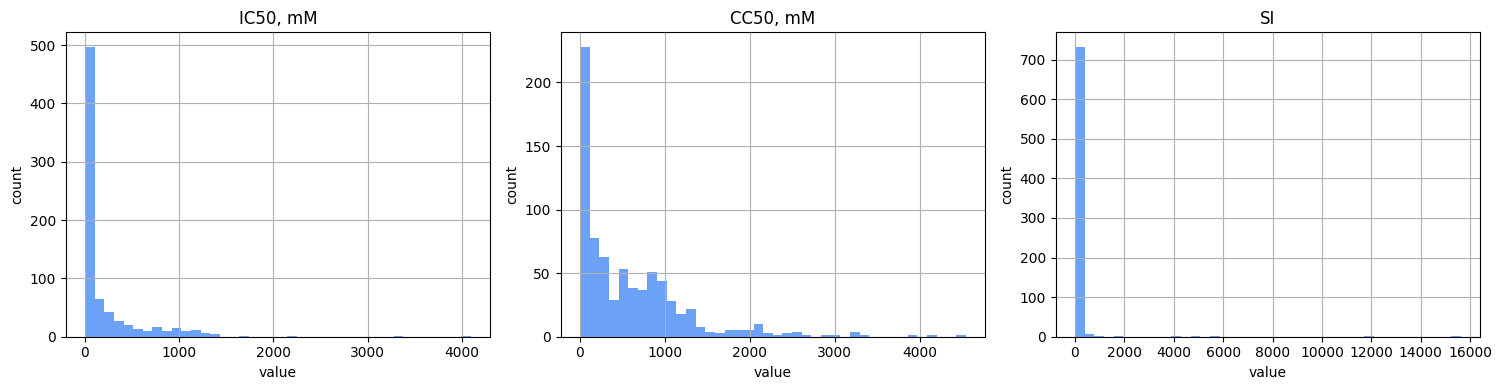

In [5]:
target_summary = train[TRAIN_TARGET_COLS].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T
custom_cols = ["count", "mean", "std", "min", "50%", "75%", "90%", "95%", "99%", "max"]
display(target_summary[custom_cols].round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, TRAIN_TARGET_COLS):
    ax.hist(train[col], bins=40, color="#3b82f6", alpha=0.75)
    ax.set_title(col)
    ax.set_xlabel("value")
    ax.set_ylabel("count")
plt.tight_layout()
plt.show()

Все три таргета с длинным правым хвостом:

| | median | p99 | max |
|---|---:|---:|---:|
| IC50 | 44 | 1334 | 4095 |
| CC50 | 377 | 3162 | 4539 |
| SI | 4 | 1281 | 15621 |

Из‑за этого RMSE сильно бьёт несколько выбросов → пробовали `raw` / `sqrt` / `log1p` и clipping хвостов в submission.

## 4. EDA: связь SI с IC50 и CC50

,"IC50, mM","CC50, mM",SI,CC50/IC50
"IC50, mM",1.0000,0.4704,-0.0605,-0.0605
"CC50, mM",0.4704,1.0000,-0.0057,-0.0057
SI,-0.0605,-0.0057,1.0000,1.0000
CC50/IC50,-0.0605,-0.0057,1.0000,1.0000


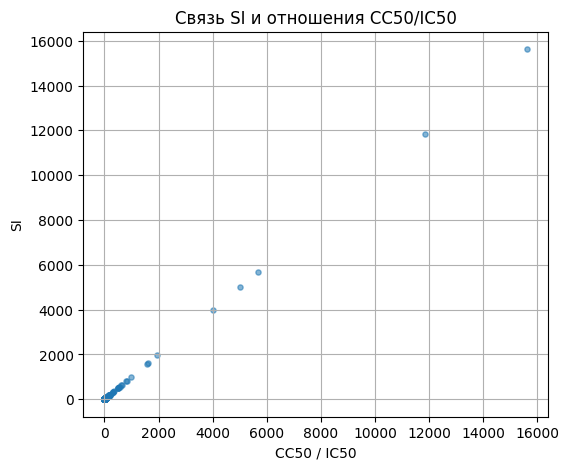

In [6]:
relation = train[TRAIN_TARGET_COLS].copy()
relation["CC50/IC50"] = relation["CC50, mM"] / relation["IC50, mM"].clip(lower=1e-9)
relation_corr = relation.corr(numeric_only=True)
display(relation_corr.round(4))

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(relation["CC50/IC50"], relation["SI"], s=14, alpha=0.55)
ax.set_xlabel("CC50 / IC50")
ax.set_ylabel("SI")
ax.set_title("Связь SI и отношения CC50/IC50")
plt.show()

`SI` почти полностью совпадает с `CC50/IC50`: corr(**SI**, **CC50/IC50**) = **1.00**.  
С `IC50` и `CC50` по отдельности связь слабая (~−0.06).

На leaderboard всё равно нужно предсказывать SI отдельной колонкой — просто формулой заменить нельзя (шум, округления, не все строки идеально согласованы).


## 5. EDA: дубликаты дескрипторов

In [7]:
def row_hash(df: pd.DataFrame) -> pd.Series:
    return hash_pandas_object(df, index=False).astype("uint64").astype(str)

groups = row_hash(train[base_feature_cols]).to_numpy()
duplicate_stats = (
    pd.DataFrame({"descriptor_hash": groups})
    .value_counts("descriptor_hash")
    .reset_index(name="rows")
)
duplicate_table = pd.DataFrame({
    "metric": ["unique_descriptor_groups", "groups_with_duplicates", "rows_in_duplicate_groups", "max_group_size"],
    "value": [
        duplicate_stats.shape[0],
        int((duplicate_stats["rows"] > 1).sum()),
        int(duplicate_stats.loc[duplicate_stats["rows"] > 1, "rows"].sum()),
        int(duplicate_stats["rows"].max()),
    ],
})
display(duplicate_table)

target_variability = train[[*TRAIN_TARGET_COLS]].copy()
target_variability["descriptor_hash"] = groups
group_variability = (
    target_variability.groupby("descriptor_hash")[TRAIN_TARGET_COLS]
    .agg(["count", "mean", "std"])
)
display(group_variability.head(8).round(3))

,metric,value
0,unique_descriptor_groups,630
1,groups_with_duplicates,60
2,rows_in_duplicate_groups,181
3,max_group_size,16


IC50, mM               CC50, mM                  SI  \
                        count      mean std    count      mean std count   
descriptor_hash                                                            
10012644623505855319        1   173.797 NaN        1   499.993 NaN     1   
10052456906273998818        1   298.774 NaN        1   640.231 NaN     1   
10064240805028789937        1    14.878 NaN        1   368.040 NaN     1   
10070923727103660661        1    79.060 NaN        1   274.513 NaN     1   
10132861228475954308        1     6.000 NaN        1   239.998 NaN     1   
10159414299227785605        1     3.799 NaN        1     9.400 NaN     1   
10196558914811493043        1   172.264 NaN        1    80.792 NaN     1   
10203037851018627209        1  1198.160 NaN        1  1198.160 NaN     1   

                                  
                        mean std  
descriptor_hash                   
10012644623505855319   2.877 NaN  
10052456906273998818   2.143 NaN  
10064240805028789937  24.737 NaN  
10070923727103660661   3.472 NaN  
10132861228475954308  39.998 NaN  
10159414299227785605   2.474 NaN  
10196558914811493043   0.469 NaN  
10203037851018627209   1.000 NaN

Дубликаты по дескрипторам есть: **630** уникальных групп, **60** групп с повторами (**181** строка, max **16** в одной группе).

Поэтому CV — `GroupKFold` по hash дескрипторов.  
Exact-match correction (подставить train-таргет при совпадении дескрипторов) пробовали — public +~0.1, в финал не взяли.

## 6. История экспериментов
Прогресс по public score:

- CatBoost baseline — **303.6**
- raw ensemble и clipping хвостов — **277.6** (−26)
- cap IC50 = 2200 — **277.3** (sanity, верх по p99 train)
- SI как blend sqrt/log1p — **265.3** (−12, главный шаг)
- ChEMBL CC50 как мета-признак — **264.3** (−1.0)

Основной выигрыш — из выбора моделей и SI-блендов, ChEMBL даёт последний небольшой шаг.
  

## 7. Локальная CV-логика и функции обучения

Метрика соревнования считается как среднее RMSE по трем таргетам на исходной шкале. Ниже функции, которыми notebook обучает финальный baseline.

In [8]:
def kaggle_score(y_true: np.ndarray, y_pred: np.ndarray) -> tuple[float, dict[str, float]]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    per_target = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))
    details = {col: float(value) for col, value in zip(SUBMISSION_TARGET_COLS, per_target)}
    return float(np.mean(per_target)), details


def transform_targets(y: pd.DataFrame | np.ndarray, method: str) -> np.ndarray:
    values = np.asarray(y, dtype=float)
    values = np.clip(values, 0.0, None)
    if method == "raw":
        return values
    if method == "sqrt":
        return np.sqrt(values)
    if method == "log1p":
        return np.log1p(values)
    raise ValueError(method)


def target_transform_caps(y: pd.DataFrame | np.ndarray, method: str, multiplier: float = 1.1) -> np.ndarray:
    values = np.asarray(y, dtype=float)
    caps = np.max(values, axis=0) * multiplier
    return transform_targets(caps.reshape(1, -1), method).reshape(-1)


def inverse_targets(y_transformed: np.ndarray, method: str, caps: np.ndarray | None = None) -> np.ndarray:
    y_transformed = np.asarray(y_transformed, dtype=float)
    if caps is not None:
        y_transformed = np.clip(y_transformed, 0.0, np.asarray(caps, dtype=float))
    else:
        y_transformed = np.clip(y_transformed, 0.0, None)
    if method == "raw":
        out = y_transformed
    elif method == "sqrt":
        out = y_transformed ** 2
    elif method == "log1p":
        out = np.expm1(y_transformed)
    else:
        raise ValueError(method)
    return np.nan_to_num(out, nan=0.0, neginf=0.0, posinf=1.0e12).clip(0.0, None)


def make_model(name: str):
    if name == "kernel_ridge":
        return MultiOutputRegressor(Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", StandardScaler()),
            ("model", KernelRidge(alpha=0.35, kernel="rbf", gamma=0.004)),
        ]))
    if name == "svr":
        return MultiOutputRegressor(Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", StandardScaler()),
            ("model", SVR(C=7.0, epsilon=0.03, gamma="scale", kernel="rbf")),
        ]))
    if name == "extra_trees":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("model", ExtraTreesRegressor(
                 n_estimators=EXTRA_TREES_N_ESTIMATORS,
                 max_features=0.75,
                 min_samples_leaf=1,
                 random_state=SEED,
                 n_jobs=MODEL_N_JOBS,
            )),
        ])
    if name == "catboost":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("model", CatBoostRegressor(
                      loss_function="MultiRMSE",
                      iterations=CATBOOST_ITERATIONS,
                      learning_rate=0.03,
                      depth=5,
                      l2_leaf_reg=8.0,
                      random_seed=SEED,
                      thread_count=CATBOOST_THREAD_COUNT,
                      # used_ram_limit=CATBOOST_USED_RAM_LIMIT,
                      verbose=False,
                      allow_writing_files=False,
            )),
        ])
    raise ValueError(name)


def fit_model_runs(model_names: list[str], target_transform: str) -> list[dict]:
    X = train[feature_cols]
    X_test = test[feature_cols]
    y_true = train[TRAIN_TARGET_COLS].to_numpy(dtype=float)
    y_fit = transform_targets(y_true, target_transform)
    caps = target_transform_caps(y_true, target_transform)
    splits = list(GroupKFold(n_splits=N_SPLITS).split(X, y_true, groups=groups))

    runs = []
    for model_name in model_names:
        started = time.time()
        oof_trans = np.zeros_like(y_fit, dtype=float)
        test_trans_folds = []
        print(f"\nОбучаю {model_name} / target_transform={target_transform}")
        for fold, (train_idx, valid_idx) in enumerate(splits, start=1):
            model = make_model(model_name)
            model.fit(X.iloc[train_idx], y_fit[train_idx])
            valid_pred_trans = np.asarray(model.predict(X.iloc[valid_idx]), dtype=float)
            test_pred_trans = np.asarray(model.predict(X_test), dtype=float)
            oof_trans[valid_idx] = valid_pred_trans
            test_trans_folds.append(test_pred_trans)
            del model
            gc.collect()
            valid_pred = inverse_targets(valid_pred_trans, target_transform, caps)
            fold_score, fold_rmse = kaggle_score(y_true[valid_idx], valid_pred)
            print(f"  fold {fold}: score={fold_score:.3f}, rmse={fold_rmse}")
        test_trans = np.mean(test_trans_folds, axis=0)
        oof_pred = inverse_targets(oof_trans, target_transform, caps)
        score, rmse = kaggle_score(y_true, oof_pred)
        elapsed = time.time() - started
        print(f"  OOF {model_name}: score={score:.3f}, seconds={elapsed:.1f}")
        runs.append({
            "model": model_name,
            "target_transform": target_transform,
            "oof_trans": oof_trans,
            "test_trans": test_trans,
            "oof_score": score,
            "rmse": rmse,
            "seconds": elapsed,
        })
    if not runs:
        raise RuntimeError(f"Нет обученных моделей для transform={target_transform}")
    return runs


def ensemble_predictions(runs: list[dict], target_transform: str) -> tuple[np.ndarray, float, dict[str, float]]:
    y_true = train[TRAIN_TARGET_COLS].to_numpy(dtype=float)
    caps = target_transform_caps(y_true, target_transform)
    oof_trans = np.mean([run["oof_trans"] for run in runs], axis=0)
    test_trans = np.mean([run["test_trans"] for run in runs], axis=0)
    oof_pred = inverse_targets(oof_trans, target_transform, caps)
    test_pred = inverse_targets(test_trans, target_transform, caps)
    score, rmse = kaggle_score(y_true, oof_pred)
    return test_pred, score, rmse


def create_submission(predictions: np.ndarray, output_path: str | Path) -> pd.DataFrame:
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    submission = sample_submission.copy()
    submission["index"] = test["index"].to_numpy()
    submission[SUBMISSION_TARGET_COLS] = predictions
    submission.to_csv(output_path, index=False)
    return submission

Imputer и модель в одном `Pipeline` → утечки median между train/valid нет. Основная валидация — `GroupKFold` по hash дескрипторов, потому что в данных есть повторяющиеся descriptor-векторы.

## 8. Baseline без внешних данных

Три ветки:
- **raw** — IC50, CC50 (`kernel_ridge` + `extra_trees`)
- **sqrt** — SI (`catboost` + `extra_trees` + `kernel_ridge`)
- **log1p** — SI (`catboost` + `svr`)


In [9]:
raw_runs = fit_model_runs(["kernel_ridge", "extra_trees"], target_transform="raw")
raw_pred, raw_oof_score, raw_rmse = ensemble_predictions(raw_runs, target_transform="raw")

sqrt_model_names = ["catboost", "extra_trees", "kernel_ridge"]
log_model_names = ["catboost", "svr"]

sqrt_runs = fit_model_runs(sqrt_model_names, target_transform="sqrt")
sqrt_pred, sqrt_oof_score, sqrt_rmse = ensemble_predictions(sqrt_runs, target_transform="sqrt")

log_runs = fit_model_runs(log_model_names, target_transform="log1p")
log_pred, log_oof_score, log_rmse = ensemble_predictions(log_runs, target_transform="log1p")

cv_summary = pd.DataFrame([
    {"branch": "raw", "models": ", ".join([r["model"] for r in raw_runs]), "oof_score": raw_oof_score, **{f"rmse_{k}": v for k, v in raw_rmse.items()}},
    {"branch": "sqrt", "models": ", ".join([r["model"] for r in sqrt_runs]), "oof_score": sqrt_oof_score, **{f"rmse_{k}": v for k, v in sqrt_rmse.items()}},
    {"branch": "log1p", "models": ", ".join([r["model"] for r in log_runs]), "oof_score": log_oof_score, **{f"rmse_{k}": v for k, v in log_rmse.items()}},
])
display(cv_summary.round(3))


Обучаю kernel_ridge / target_transform=raw
  fold 1: score=686.502, rmse={'IC50': 391.2361241049271, 'CC50': 425.68778664168974, 'SI': 1242.5817138446143}
  fold 2: score=389.306, rmse={'IC50': 398.369618830892, 'CC50': 642.2901889891755, 'SI': 127.25671462456339}
  fold 3: score=391.555, rmse={'IC50': 290.4581423750839, 'CC50': 450.8041929529465, 'SI': 433.4035692298087}
  fold 4: score=255.351, rmse={'IC50': 258.60903154576914, 'CC50': 412.207573139759, 'SI': 95.23680075621837}
  fold 5: score=574.516, rmse={'IC50': 287.96178388426637, 'CC50': 438.9595804889186, 'SI': 996.6272289204718}
  OOF kernel_ridge: score=518.196, seconds=1.9

Обучаю extra_trees / target_transform=raw
  fold 1: score=674.506, rmse={'IC50': 358.49364835647395, 'CC50': 382.7181143008856, 'SI': 1282.3050316840468}
  fold 2: score=373.618, rmse={'IC50': 434.69204587192223, 'CC50': 546.3728438959791, 'SI': 139.78801378157138}
  fold 3: score=392.871, rmse={'IC50': 296.89846870834106, 'CC50': 427.8228266136444, 'SI

,branch,models,oof_score,rmse_IC50,rmse_CC50,rmse_SI
0,raw,"kernel_ridge, extra_trees",511.300,328.408,453.531,751.960
1,sqrt,"catboost, extra_trees, kernel_ridge",525.794,329.976,466.833,780.573
2,log1p,"catboost, svr",542.242,345.749,490.051,790.928


OOF GroupKFold (строгий, с группами дубликатов):

| ветка | OOF score | RMSE SI |
|---|---:|---:|
| raw | 510.9 | 751.6 |
| sqrt | 525.6 | 780.4 |
| log1p | 542.2 | 790.9 |



На public leaderboard score ~**265**, на OOF ~**510** — gap большой из-за GroupKFold по дубликатам и маленького train (751 строка). Финальные гипотезы (cap 2200, blend SI, external) проверяли по сочетанию OOF и public: public-test 25% — стабильный второй сигнал, OOF на GroupKFold заметно строже.  

## 9. Сборка baseline submission

- **IC50** ← raw, clip max **2200** (на test p99=max=2200 — cap срабатывает)
- **CC50** ← raw
- **SI** ← `sqrt + 1.02 * (log1p − sqrt)`, вес 1.02 — небольшая экстраполяция log-ветки за пределы sqrt. OOF на GroupKFold чувствителен к дубликатам, поэтому решение принимали с учётом OOF и public одновременно.

In [10]:
baseline_pred = raw_pred.copy()

# clip IC50 — верхний хвост на test
baseline_pred[:, 0] = np.clip(baseline_pred[:, 0], 0.0, 2200.0)

# SI: смесь sqrt- и log1p-веток
sqrt_si = np.clip(sqrt_pred[:, 2], 0.0, 500.0)
log_si = np.clip(log_pred[:, 2], 0.0, 500.0)
baseline_pred[:, 2] = np.clip(sqrt_si + 1.02 * (log_si - sqrt_si), 0.0, None)

baseline_submission = create_submission(baseline_pred, OUTPUT_DIR / "submission_raw_ic2200_si_sqrt_log_w102.csv")
display(baseline_submission.head())
print("Saved:", OUTPUT_DIR / "submission_raw_ic2200_si_sqrt_log_w102.csv")

baseline_stats = baseline_submission[SUBMISSION_TARGET_COLS].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T
display(baseline_stats.round(3))

,index,IC50,CC50,SI
0,0,108.718625,203.002890,4.004467
1,1,200.011846,391.046600,4.200796
2,2,55.674266,288.980319,5.390596
3,3,326.754430,438.700145,2.399882
4,4,227.331971,366.145096,2.537857


Saved: submissions/submission_raw_ic2200_si_sqrt_log_w102.csv


,count,mean,std,min,50%,90%,95%,99%,max
IC50,250.0,247.383,336.535,0.000,147.016,556.372,786.925,2200.000,2200.000
CC50,250.0,644.295,530.357,1.867,495.670,1213.375,1615.875,2801.158,3052.593
SI,250.0,12.722,25.380,1.065,5.077,28.447,42.707,129.109,287.681


Сохранён `submission_raw_ic2200_si_sqrt_log_w102.csv`, public **265.31**.

Статистика test-predictions: IC50 mean **247.3** (max **2200** после clip), CC50 mean **644.6**  (max **3054**), SI mean **12.7** (max **287.68**).  
Дальше улучшаем только CC50 через external.

## 10. Откуда взялся external CSV (ChEMBL)

Файл не из Kaggle и не содержит ответов test.  
~2000 CC50-like записей из ChEMBL → uM → RDKit-дескрипторы → median по SMILES.

Код пересборки ниже **выключен по умолчанию** (нужен интернет + rdkit).

In [11]:
RUN_CHEMBL_PREPROCESSING = False # True — только если пересобираете CSV из ChEMBL

CHEMBL_OUTPUT_PATH = Path("external_data/chembl_cytotoxicity_cc50_strict_2000_aggregated.csv")
CHEMBL_RAW_LIMIT = 2000
CHEMBL_QUERY_TERMS = [
      "CC50",
      "cytotoxicity",
      "cell viability",
      "MDCK cytotoxicity",
      "Vero cytotoxicity",
      "MTT",
      "cellular toxicity",
  ]
STRICT_CC50_TYPES = {"CC50", "TC50", "LC50"}

In [12]:
def install_chembl_preprocessing_dependencies() -> None:
    """Ставим зависимости только если реально пересобираем внешний датасет."""
    import subprocess
    import sys

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "chembl_webresource_client",
        "rdkit",
    ])


def looks_like_cytotoxicity_assay(row: dict) -> bool:
    text = " ".join(
        str(row.get(key) or "")
        for key in ["description", "assay_description", "assay_organism", "target_organism"]
    ).lower()
    positive = [
        "cc50",
        "cytotoxic",
        "cytotoxicity",
        "cell viability",
        "cell death",
        "cellular toxicity",
        "mtt",
        "toxicity",
    ]
    negative = [
        "ratio of cc50",
        "cc50/ec50",
        "therapeutic index",
        "selectivity index",
        "si ",
    ]
    return any(word in text for word in positive) and not any(word in text for word in negative)


def compact_chembl_activity(row: dict) -> dict:
    return {
        "molecule_chembl_id": row.get("molecule_chembl_id"),
        "canonical_smiles": row.get("canonical_smiles")
        or (row.get("molecule_structures") or {}).get("canonical_smiles"),
        "standard_type": row.get("standard_type"),
        "standard_relation": row.get("standard_relation"),
        "standard_value": row.get("standard_value"),
        "standard_units": row.get("standard_units"),
        "assay_chembl_id": row.get("assay_chembl_id"),
        "assay_description": row.get("assay_description"),
        "assay_type": row.get("assay_type"),
        "assay_organism": row.get("assay_organism"),
        "target_chembl_id": row.get("target_chembl_id"),
        "target_organism": row.get("target_organism"),
        "document_chembl_id": row.get("document_chembl_id"),
        "data_validity_comment": row.get("data_validity_comment"),
    }


def find_chembl_cytotoxicity_assays(new_client, query_terms: list[str], limit: int) -> list[str]:
    assay_ids: list[str] = []
    seen: set[str] = set()
    for query in query_terms:
        rows = new_client.assay.filter(description__icontains=query).only(
            ["assay_chembl_id", "description", "assay_organism", "assay_type"]
        )
        for row in rows:
            if not looks_like_cytotoxicity_assay(row):
                continue
            assay_id = row.get("assay_chembl_id")
            if not assay_id or assay_id in seen:
                continue
            seen.add(assay_id)
            assay_ids.append(assay_id)
            if len(assay_ids) >= limit:
                return assay_ids
    return assay_ids


def fetch_chembl_strict_cytotoxicity_rows(limit: int = CHEMBL_RAW_LIMIT) -> pd.DataFrame:
    from chembl_webresource_client.new_client import new_client

    assay_ids = find_chembl_cytotoxicity_assays(new_client, CHEMBL_QUERY_TERMS, limit=max(limit, 500))
    print(f"Найдено candidate cytotoxicity assays: {len(assay_ids)}")

    rows: list[dict] = []
    seen: set[tuple] = set()
    chunk_size = 25
    for start in range(0, len(assay_ids), chunk_size):
        chunk = assay_ids[start : start + chunk_size]
        page = new_client.activity.filter(
            standard_type__in=sorted(STRICT_CC50_TYPES),
            standard_relation="=",
            assay_chembl_id__in=chunk,
        ).only([
            "molecule_chembl_id",
            "molecule_structures",
            "canonical_smiles",
            "standard_type",
            "standard_relation",
            "standard_value",
            "standard_units",
            "assay_chembl_id",
            "assay_description",
            "assay_type",
            "assay_organism",
            "target_chembl_id",
            "target_organism",
            "document_chembl_id",
            "data_validity_comment",
        ])
        for row in page:
            item = compact_chembl_activity(row)
            key = (
                item["molecule_chembl_id"],
                item["standard_type"],
                item["standard_value"],
                item["assay_chembl_id"],
            )
            if key in seen:
                continue
            seen.add(key)
            rows.append(item)
            if len(rows) >= limit:
                break
        if len(rows) >= limit:
            break

    result = pd.DataFrame(rows)
    print(f"Загружено raw ChEMBL rows: {len(result)}")
    if not result.empty:
        display(result["standard_type"].value_counts(dropna=False).rename("rows").reset_index())
        display(result["standard_units"].value_counts(dropna=False).head(10).rename("rows").reset_index())
    return result


def normalize_chembl_activity_to_um(raw: pd.DataFrame) -> pd.DataFrame:
    data = raw.copy()
    data["activity_value_raw"] = pd.to_numeric(data["standard_value"], errors="coerce")
    units = data["standard_units"].astype(str).str.strip().str.lower()
    unit_multiplier_to_um = {
        "pm": 1e-6,
        "nm": 1e-3,
        "um": 1.0,
        "µm": 1.0,
        "μm": 1.0,
        "mm": 1e3,
    }
    data["_unit_norm"] = units.str.replace(" ", "", regex=False)
    data["_multiplier"] = data["_unit_norm"].map(unit_multiplier_to_um)
    data = data[
        data["standard_type"].astype(str).str.upper().isin(STRICT_CC50_TYPES)
        & data["standard_relation"].eq("=")
        & data["activity_value_raw"].notna()
        & data["_multiplier"].notna()
        & data["canonical_smiles"].notna()
    ].copy()
    data["target"] = "CC50"
    data["activity_type_raw"] = data["standard_type"]
    data["activity_units_raw"] = data["standard_units"]
    data["activity_value_um"] = data["activity_value_raw"] * data["_multiplier"]
    data = data[np.isfinite(data["activity_value_um"]) & data["activity_value_um"].gt(0)].copy()
    data = data.drop(columns=["_unit_norm", "_multiplier"])
    print(f"После нормализации в uM: {len(data)} rows")
    return data


def calc_competition_rdkit_descriptors(smiles: str, descriptor_columns: list[str]) -> dict[str, float] | None:
    from rdkit import Chem
    from rdkit.Chem import Descriptors

    if pd.isna(smiles) or str(smiles).strip() == "":
        return None
    mol = Chem.MolFromSmiles(str(smiles).strip())
    if mol is None:
        return None
    values = Descriptors.CalcMolDescriptors(mol, missingVal=np.nan, silent=True)
    return {column: values.get(column, np.nan) for column in descriptor_columns}


def add_rdkit_descriptor_columns(data: pd.DataFrame, descriptor_columns: list[str]) -> pd.DataFrame:
    descriptor_rows: list[dict[str, float]] = []
    valid_indices: list[int] = []
    for idx, smiles in data["canonical_smiles"].items():
        descriptor_values = calc_competition_rdkit_descriptors(smiles, descriptor_columns)
        if descriptor_values is None:
            continue
        descriptor_rows.append(descriptor_values)
        valid_indices.append(idx)

    descriptors = pd.DataFrame(descriptor_rows, columns=descriptor_columns)
    metadata = data.loc[valid_indices].reset_index(drop=True)
    result = pd.concat([metadata, descriptors.reset_index(drop=True)], axis=1)
    print(f"После расчета RDKit descriptors: {len(result)} rows")
    return result


def aggregate_external_by_smiles_and_target(data: pd.DataFrame, descriptor_columns: list[str]) -> pd.DataFrame:
    value_column = "activity_value_um"
    group_cols = ["canonical_smiles", "target"]
    metadata_first = {
        column: "first"
        for column in data.columns
        if column not in group_cols and column not in descriptor_columns and column != value_column
    }
    descriptor_first = {column: "first" for column in descriptor_columns}
    aggregated = (
        data.groupby(group_cols, as_index=False)
        .agg({value_column: "median", **metadata_first, **descriptor_first})
        .reset_index(drop=True)
    )
    aggregated["external_measurement_count"] = (
        data.groupby(group_cols)[value_column].size().to_numpy()
    )
    print(f"После агрегации canonical_smiles + target: {len(aggregated)} rows")
    return aggregated


def rebuild_chembl_cc50_dataset(output_path: Path = CHEMBL_OUTPUT_PATH) -> pd.DataFrame:
    install_chembl_preprocessing_dependencies()
    raw = fetch_chembl_strict_cytotoxicity_rows(limit=CHEMBL_RAW_LIMIT)
    normalized = normalize_chembl_activity_to_um(raw)
    with_descriptors = add_rdkit_descriptor_columns(normalized, base_feature_cols)
    aggregated = aggregate_external_by_smiles_and_target(with_descriptors, base_feature_cols)

    output_path.parent.mkdir(parents=True, exist_ok=True)
    aggregated.to_csv(output_path, index=False)
    print("Сохранен внешний датасет:", output_path)
    return aggregated


if RUN_CHEMBL_PREPROCESSING:
    rebuilt_external = rebuild_chembl_cc50_dataset(CHEMBL_OUTPUT_PATH)
    external_path = CHEMBL_OUTPUT_PATH
    display(rebuilt_external.head())
else:
    print("Пересборка ChEMBL датасета выключена. Используем уже подготовленный CSV:", external_path)

Пересборка ChEMBL датасета выключена. Используем уже подготовленный CSV: external_data/chembl_cytotoxicity_cc50_strict_2000_aggregated.csv


В финальном прогоне используем готовый CSV из `external_data/`.  
Пересборка из ChEMBL — appendix для воспроизводимости, не обязательна для submission.

## 11. External CC50 как доп. признак

Схема: обучаем модель на ChEMBL (дескрипторы → CC50), получаем `external_cc50_prediction` для train/test, добавляем как **+1 признак** при обучении CC50 на competition train.

IC50 и SI не трогаем.

  Сравнение схем интеграции external для CC50, OOF RMSE:

 | схема | OOF RMSE | Δ vs baseline |
  |---|---:|---:|
  | baseline без external | 500.7 | — |
  | external rows напрямую в train | 557.8 | **+57.1** |
  | external как мета-признак, scale=1 | 501.4 | +0.7 |
  | external как мета-признак, scale=20 | 500.1 | **−0.6** |
  

  Прямое добавление внешних строк ухудшает CC50 — шкалы и условия экспериментов
  разные. Через мета-признак сигнал нейтрален при scale=1 и даёт небольшое
  улучшение при scale=20 — его и взяли в финал.

In [13]:
def transform_1d(y: np.ndarray, method: str) -> np.ndarray:
    y = np.clip(np.asarray(y, dtype=float), 0.0, None)
    if method == "raw":
        return y
    if method == "sqrt":
        return np.sqrt(y)
    if method == "log1p":
        return np.log1p(y)
    raise ValueError(method)


def inverse_1d(y: np.ndarray, method: str) -> np.ndarray:
    y = np.asarray(y, dtype=float)
    if method == "raw":
        out = y
    elif method == "sqrt":
        out = np.square(np.clip(y, 0.0, None))
    elif method == "log1p":
        out = np.expm1(y)
    else:
        raise ValueError(method)
    return np.nan_to_num(out, nan=0.0, neginf=0.0, posinf=1.0e12).clip(0.0, None)


def make_extra_trees_single(seed: int = SEED) -> Pipeline:
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("model", ExtraTreesRegressor(
                    n_estimators=EXTRA_TREES_N_ESTIMATORS,
                    max_features=0.75,
                    min_samples_leaf=1,
                    random_state=SEED,
                    n_jobs=MODEL_N_JOBS,
        )),
    ])


def clean_by_train_range(train_x: pd.DataFrame, external_x: pd.DataFrame, test_x: pd.DataFrame):
    train_clean = train_x.astype(float).replace([np.inf, -np.inf], np.nan)
    external_clean = external_x.astype(float).replace([np.inf, -np.inf], np.nan)
    test_clean = test_x.astype(float).replace([np.inf, -np.inf], np.nan)
    lower = train_clean.min(axis=0, skipna=True)
    upper = train_clean.max(axis=0, skipna=True)
    external_clean = external_clean.clip(lower=lower, upper=upper, axis=1)
    test_clean = test_clean.clip(lower=lower, upper=upper, axis=1)
    return train_clean, external_clean, test_clean


def build_external_cc50_prediction(external_csv: Path) -> tuple[np.ndarray, pd.DataFrame]:
    external = pd.read_csv(external_csv)
    required_cols = set(feature_cols) | {"target", "activity_value_um"}
    missing = sorted(required_cols - set(external.columns))
    if missing:
        raise ValueError(f"Во внешнем файле не хватает колонок: {missing[:10]}")

    ext_target = external["target"].astype(str).str.upper()
    external_rows = external[ext_target.eq("CC50")].copy()
    external_rows = external_rows[pd.to_numeric(external_rows["activity_value_um"], errors="coerce").notna()].copy()
    if external_rows.empty:
        raise ValueError("Во внешнем файле нет строк target=CC50 с числовым activity_value_um")

    x_train, x_ext, x_test = clean_by_train_range(
        train[feature_cols],
        external_rows[feature_cols],
        test[feature_cols],
    )

    # scale=20 — лучший among {1, 5, 10, 20} по OOF CC50 (см. таблицу выше)
    y_ext = pd.to_numeric(external_rows["activity_value_um"], errors="coerce").to_numpy(dtype=float) * 20.0

    external_model = make_extra_trees_single(SEED)
    external_model.fit(x_ext, transform_1d(y_ext, "log1p"))
    ext_pred_train = inverse_1d(external_model.predict(x_train), "log1p")
    ext_pred_test = inverse_1d(external_model.predict(x_test), "log1p")

    x_train_meta = x_train.copy()
    x_test_meta = x_test.copy()
    x_train_meta["external_cc50_prediction"] = np.log1p(np.clip(ext_pred_train, 0.0, None))
    x_test_meta["external_cc50_prediction"] = np.log1p(np.clip(ext_pred_test, 0.0, None))

    y_train_cc50 = train["CC50, mM"].to_numpy(dtype=float)
    competition_model = make_extra_trees_single(SEED)
    competition_model.fit(x_train_meta, transform_1d(y_train_cc50, "log1p"))
    cc50_pred = inverse_1d(competition_model.predict(x_test_meta), "log1p")
    cc50_pred = np.clip(cc50_pred, 0.0, 3200.0)

    info = pd.DataFrame([
        {"metric": "external_rows_used", "value": len(external_rows)},
        {"metric": "external_activity_um_mean", "value": float(np.mean(y_ext / 20.0))},
        {"metric": "external_scaled_target_mean", "value": float(np.mean(y_ext))},
        {"metric": "cc50_meta_prediction_mean", "value": float(np.mean(cc50_pred))},
        {"metric": "cc50_meta_prediction_p95", "value": float(np.quantile(cc50_pred, 0.95))},
        {"metric": "cc50_meta_prediction_max", "value": float(np.max(cc50_pred))},
    ])
    return cc50_pred, info


def blend_cc50(base_pred: np.ndarray, cc50_external_pred: np.ndarray, beta: float) -> np.ndarray:
    result = base_pred.copy()
    result[:, 1] = (1.0 - beta) * result[:, 1] + beta * cc50_external_pred
    result[:, 1] = np.clip(result[:, 1], 0.0, 3200.0)
    return result

External влияет только на CC50. Beta blend **0.15** — основной; **0.22** — пробовали, public score чуть лучше (264.19 vs 264.30), но меньше согласован с OOF, поэтому в финал берём 0.15.

## 12. Финальные submission

Если external найден — сохраняем `b15` и `b22`. Для отчёта берём **b15**.

In [14]:
if external_path is None:
    print("Внешний ChEMBL CC50 файл не найден. Сохраняю только non-external baseline.")
    final_b15 = baseline_submission.copy()
    final_b22 = None
else:
    cc50_external_pred, external_info = build_external_cc50_prediction(external_path)
    display(external_info.round(3))

    pred_b15 = blend_cc50(baseline_pred, cc50_external_pred, beta=0.15)
    pred_b22 = blend_cc50(baseline_pred, cc50_external_pred, beta=0.22)

    final_b15 = create_submission(pred_b15, OUTPUT_DIR / "submission_raw_best_cc50ext_b15.csv")
    final_b22 = create_submission(pred_b22, OUTPUT_DIR / "submission_raw_best_cc50ext_b22.csv")

    comparison = pd.DataFrame([
        {"submission": "submission_raw_ic2200_si_sqrt_log_w102.csv", "public_score": 265.31, "role": "лучший baseline без внешних данных"},
        {"submission": "submission_raw_best_cc50ext_b15.csv", "public_score": 264.30, "role": "основной вариант для защиты"},
        {"submission": "submission_raw_best_cc50ext_b22.csv", "public_score": 264.19, "role": "альтернативный blend, не основной"},
    ])
    display(comparison)

    final_stats = pd.concat(
        {
            "b15": final_b15[SUBMISSION_TARGET_COLS].describe().T,
            "b22": final_b22[SUBMISSION_TARGET_COLS].describe().T,
        },
        axis=0,
    )
    display(final_stats.round(3))

display(final_b15.head())

,metric,value
0,external_rows_used,813.000
1,external_activity_um_mean,82.116
2,external_scaled_target_mean,1642.319
3,cc50_meta_prediction_mean,513.097
4,cc50_meta_prediction_p95,1650.285
5,cc50_meta_prediction_max,3200.000


,submission,public_score,role
0,submission_raw_ic2200_si_sqrt_log_w102.csv,265.31,лучший baseline без внешних данных
1,submission_raw_best_cc50ext_b15.csv,264.30,основной вариант для защиты
2,submission_raw_best_cc50ext_b22.csv,264.19,"альтернативный blend, не основной"


count     mean      std    min      25%      50%      75%       max
b15 IC50  250.0  247.383  336.535  0.000   62.578  147.016  287.876  2200.000
    CC50  250.0  624.615  531.499  4.976  270.046  475.914  826.649  3074.704
    SI    250.0   12.722   25.380  1.065    3.081    5.077   12.521   287.681
b22 IC50  250.0  247.383  336.535  0.000   62.578  147.016  287.876  2200.000
    CC50  250.0  615.431  532.571  6.427  265.853  466.237  799.570  3085.023
    SI    250.0   12.722   25.380  1.065    3.081    5.077   12.521   287.681

,index,IC50,CC50,SI
0,0,108.718625,192.331278,4.004467
1,1,200.011846,377.388907,4.200796
2,2,55.674266,287.190923,5.390596
3,3,326.754430,393.047927,2.399882
4,4,227.331971,349.838253,2.537857


**Итог:** `submission_raw_best_cc50ext_b15.csv`, public **264.30**.

| | public | CC50 mean (test pred) |
|---|---:|---:|
| baseline | 265.31 | 648.0 |
| b15 | 264.30 | 627.8 |
| b22 | 264.19 | 618.4 |

IC50 и SI между b15/b22/baseline совпадают — меняется только CC50.